# Практическое задание №2. Реализация логистической регрессии с градиентным спуском

In [1]:
from sklearn import datasets
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def log_loss(w, X, y):

    n_samples = X.shape[1]

    z = np.dot(w.T, X)
    predictions = sigmoid(z)

    loss = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    grad = (1/n_samples) * np.dot(X, (predictions - y).T)

    return loss, grad


def optimize(w, X, y, n_iterations, eta):
    losses = []

    for i in range(n_iterations):
        loss, grad = log_loss(w, X, y)
        w = w - eta * grad
        losses.append(loss)

    return w, losses


def predict(w, X, b=0.5):
    z = np.dot(w.T, X)
    probabilities = sigmoid(z)
    y_predicted = np.zeros((1, X.shape[1]))

    for i in range(probabilities.shape[1]):
        if probabilities[0, i] > b:
            y_predicted[0, i] = 1
        else:
            y_predicted[0, i] = 0

    return y_predicted

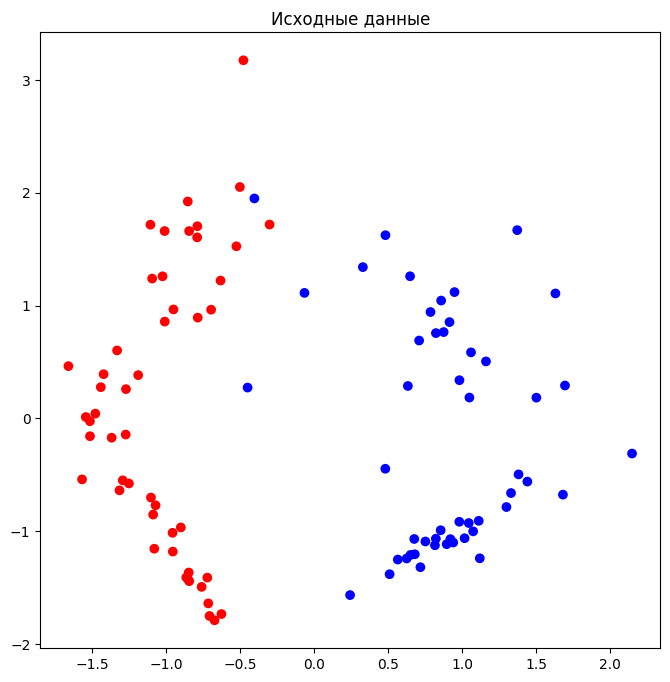

In [3]:
classes = datasets.make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=1)

colors = ListedColormap(['red', 'blue'])

plt.figure(figsize=(8, 8))
plt.scatter([x[0] for x in classes[0]], [x[1] for x in classes[0]], c=classes[1], cmap=colors)
plt.title('Исходные данные')

plt.show()

In [4]:
np.random.seed(12)
shuffle_index = np.random.permutation(classes[0].shape[0])
X_shuffled, y_shuffled = classes[0][shuffle_index], classes[1][shuffle_index]

train_proportion = 0.7
train_test_cut = int(len(classes[0]) * train_proportion)

X_train, X_test, y_train, y_test = \
    X_shuffled[:train_test_cut], \
    X_shuffled[train_test_cut:], \
    y_shuffled[:train_test_cut], \
    y_shuffled[train_test_cut:]

print("Размер массива признаков обучающей выборки", X_train.shape)
print("Размер массива признаков тестовой выборки", X_test.shape)
print("Размер массива ответов для обучающей выборки", y_train.shape)
print("Размер массива ответов для тестовой выборки", y_test.shape)

Размер массива признаков обучающей выборки (70, 2)
Размер массива признаков тестовой выборки (30, 2)
Размер массива ответов для обучающей выборки (70,)
Размер массива ответов для тестовой выборки (30,)


In [5]:
X_train_tr = X_train.transpose()
y_train_tr = y_train.reshape(1, y_train.shape[0])
X_test_tr = X_test.transpose()
y_test_tr = y_test.reshape(1, y_test.shape[0])

In [6]:
w0 = np.zeros((X_train_tr.shape[0], 1))

n_iterations = 1000
eta = 0.05

w, losses = optimize(w0, X_train_tr, y_train_tr, n_iterations, eta)

y_predicted_test = predict(w, X_test_tr)
y_predicted_train = predict(w, X_train_tr)

train_accuracy = 100.0 - np.mean(np.abs(y_predicted_train - y_train_tr)*100.0)
test_accuracy = 100.0 - np.mean(np.abs(y_predicted_test-y_test_tr)*100.0)

print(f"Итоговый вектор весов w: {w}")
print(f"Точность на обучающей выборке: {train_accuracy:.3f}")
print(f"Точность на тестовой выборке: {test_accuracy:.3f}")

Итоговый вектор весов w: [[3.72659902]
 [0.22383415]]
Точность на обучающей выборке: 98.571
Точность на тестовой выборке: 96.667


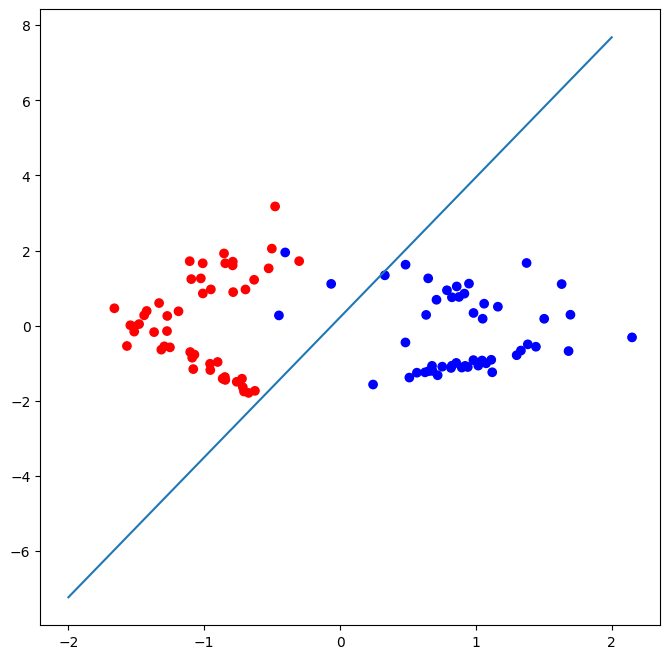

In [7]:
data = np.linspace(-2, 2, 100)

plt.figure(figsize=(8, 8))
plt.scatter([x[0] for x in classes[0]], [x[1] for x in classes[0]], c=classes[1], cmap=colors)
plt.plot(data, w[0,0]*data+w[1,0])

plt.show()



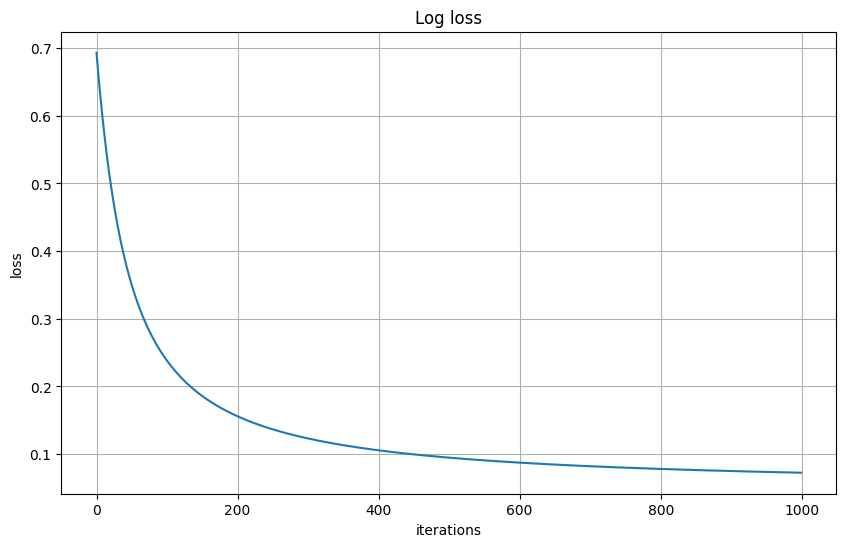

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(losses)), losses)
plt.title('Log loss')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.grid(True)
plt.show()

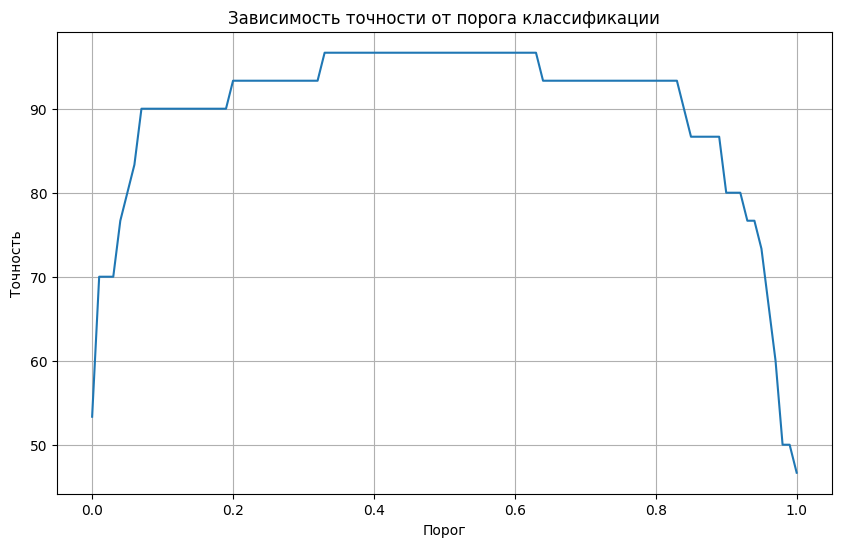

In [9]:
test_acc = []
b_l = []

for b in range(0, 101):
  y_predicted_test = predict(w, X_test_tr, b/100)
  y_predicted_train = predict(w, X_train_tr, b/100)

  test_accuracy = 100.0 - np.mean(np.abs(y_predicted_test-y_test_tr)*100.0)

  b_l.append(b/100)
  test_acc.append(test_accuracy)

plt.figure(figsize=(10, 6))
plt.plot(b_l, test_acc)
plt.title('Зависимость точности от порога классификации')
plt.xlabel('Порог')
plt.ylabel('Точность')
plt.grid(True)
plt.show()

Дополнительные вопросы:
1. Как влияет размер шага eta на сходимость алгоритма?

На графике видно, что размер шага eta значительно влияет на скорость обучения. При eta=0.001 алгоритм сходится очень медленно. При eta=0.01 и 0.1 наблюдается оптимальная сходимость. При eta=0.5 и 1.0 появляются резкие колебания.


2. Что произойдет, если выбрать слишком маленькое или слишком большое количество итераций n_iterations?

При малом количестве итераций алгоритм не успевает обучиться - функция потерь остается высокой. При 100-500 итерациях уже видно значительное улучшение. Дальнейшее увеличение до 1000 и 5000 итераций не дает существенного улучшения (риск переобучения и лишние вычисления).

3. Почему логистическая регрессия подходит для задач только бинарной классификации?

Логистическая регрессия использует сигмоидную функцию, которая по своей природе бинарна: P(y=1|x) = σ(z), P(y=0|x) = 1 - P(y=1|x). Для многоклассовой классификации этот подход не работает, так как сумма вероятностей всех классов должна равняться 1, что невозможно обеспечить с помощью сигмоидной функции.

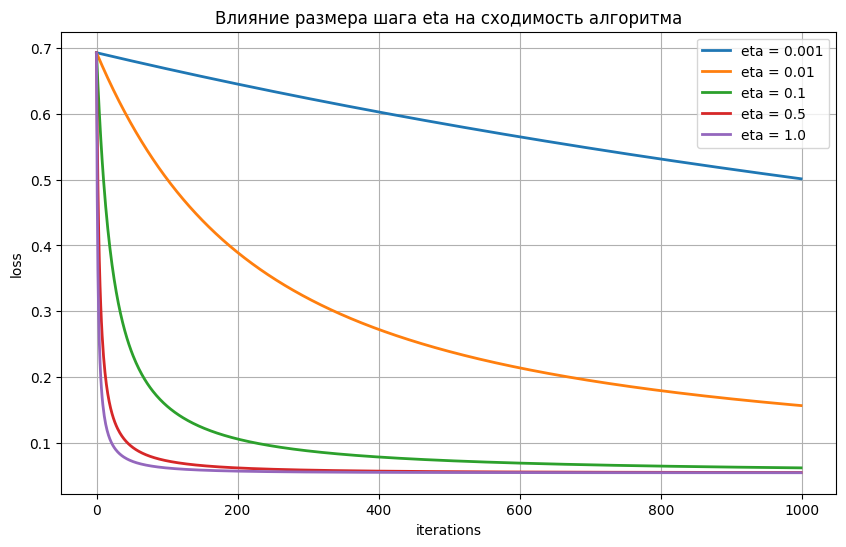

In [10]:
etas = [0.001, 0.01, 0.1, 0.5, 1.0]
plt.figure(figsize=(10, 6))

for eta in etas:
    w0_test = np.zeros((X_train_tr.shape[0], 1))
    w_test, losses_test = optimize(w0_test, X_train_tr, y_train_tr, n_iterations, eta)

    plt.plot(range(len(losses_test)), losses_test, linewidth=2, label=f'eta = {eta}')

plt.title('Влияние размера шага eta на сходимость алгоритма')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.grid(True)
plt.legend()
plt.show()

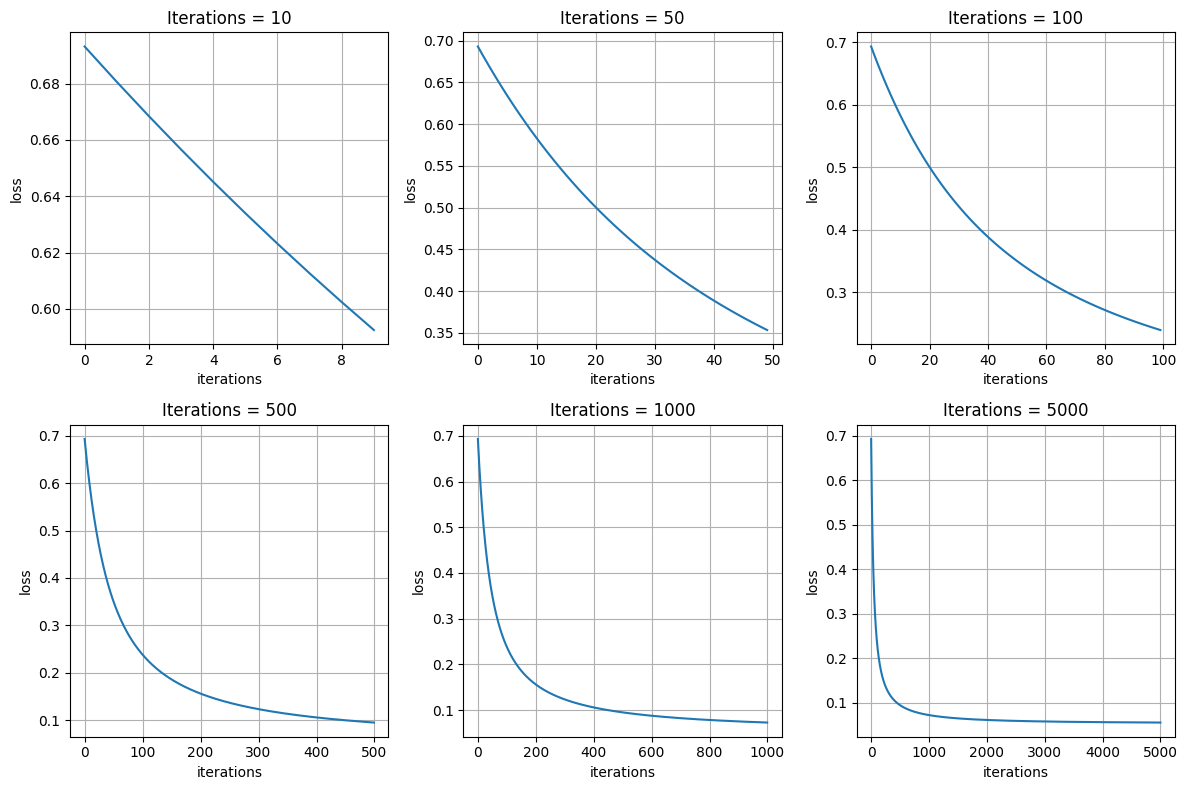

In [11]:
iterations_list = [10, 50, 100, 500, 1000, 5000]
plt.figure(figsize=(12, 8))

for i, n_iter in enumerate(iterations_list):
    w0_test = np.zeros((X_train_tr.shape[0], 1))
    w_test, losses_test = optimize(w0_test, X_train_tr, y_train_tr, n_iter, 0.05)

    plt.subplot(2, 3, i+1)
    plt.plot(range(len(losses_test)), losses_test)
    plt.title(f'Iterations = {n_iter}')
    plt.xlabel('iterations')
    plt.ylabel('loss')
    plt.grid(True)

plt.tight_layout()
plt.show()